# Benchmarking spot counting using Vision Language Models

Now, we want to apply [moondream](https://huggingface.co/vikhyatk/moondream2) on different and potentially more challenging biological examples to see how it performs.

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer
from PIL import Image, ImageDraw
from image_utilities import numpy_to_bytestream, extract_json, generate_spots
from tqdm import tqdm
import stackview
from skimage import data
import numpy as np
from skimage import img_as_ubyte

model = AutoModelForCausalLM.from_pretrained(
    "vikhyatk/moondream2",
    revision="2025-01-09",
    trust_remote_code=True,
    # Comment to run on CPU. To use the GPU, you need about 5 GB of GPU Memory.
    # GPU "cuda"
    # On Apple Silicon, use "mps"
    device_map={"": "mps"}
)

## Cell nuclei


StackViewNDArray([[ 8868,  6923,  5690, ..., 13942, 12804, 14653],
                  [ 7113,  5501,  5216, ..., 16739, 13657, 15554],
                  [ 5833,  7160,  5928, ..., 15838, 16739, 17166],
                  ...,
                  [ 2513,  3936,  3414, ...,  3699,  4126,  4220],
                  [ 3319,  3272,  2513, ...,  3699,  3367,  2940],
                  [ 3130,  3794,  3225, ...,  2987,  3746,  4315]],
                 shape=(256, 256), dtype=uint16)
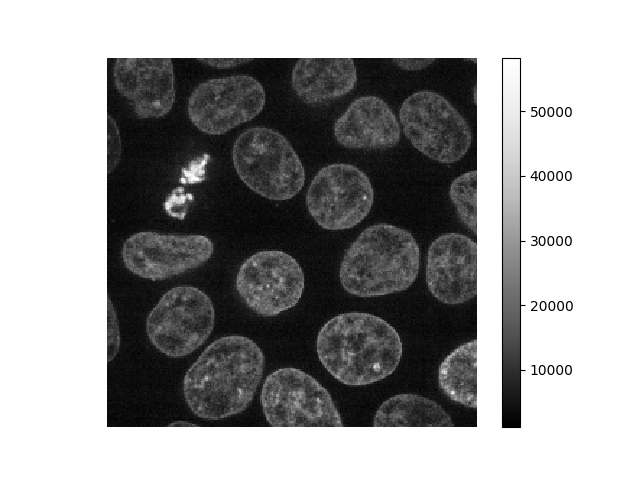
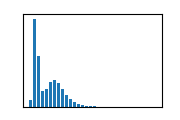

In [ ]:
# Load the human mitosis dataset
image = data.cells3d()[30, 1, :, :]

# Display the image
stackview.insight(image)

In [ ]:
image_uint8 = img_as_ubyte(image)
pil_image = Image.fromarray(image_uint8)

In [49]:
encoded_image = model.encode_image(pil_image)

In [50]:
# Pointing
print("\nPointing: 'bright spot'")
points = model.point(encoded_image, "Mark the bright dots")["points"]
print(f"Found {len(points)} bright spot(s)")


Pointing: 'bright spot'
Found 50 bright spot(s)


In [51]:
box_half_size = 5 / image.shape[0]
bb = [{'x':p['x']-box_half_size, 'y':p['y']-box_half_size, 'width':2*box_half_size, 'height':2*box_half_size } for p in points]

StackViewNDArray([[[34, 34, 34],
                   [25, 25, 25],
                   [20, 20, 20],
                   ...,
                   [57, 57, 57],
                   [52, 52, 52],
                   [60, 60, 60]],

                  [[26, 26, 26],
                   [19, 19, 19],
                   [18, 18, 18],
                   ...,
                   [69, 69, 69],
                   [55, 55, 55],
                   [64, 64, 64]],

                  [[21, 21, 21],
                   [27, 27, 27],
                   [21, 21, 21],
                   ...,
                   [65, 65, 65],
                   [69, 69, 69],
                   [71, 71, 71]],

                  ...,

                  [[ 6,  6,  6],
                   [12, 12, 12],
                   [10, 10, 10],
                   ...,
                   [11, 11, 11],
                   [13, 13, 13],
                   [13, 13, 13]],

                  [[ 9,  9,  9],
                   [ 9,  9,  9],
                   [ 6,  6,  6],
                   ...,
                   [11, 11, 11],
                   [10, 10, 10],
                   [ 8,  8,  8]],

                  [[ 9,  9,  9],
                   [12, 12, 12],
                   [ 9,  9,  9],
                   ...,
                   [ 8,  8,  8],
                   [11, 11, 11],
                   [14, 14, 14]]], shape=(256, 256, 3), dtype=uint8)
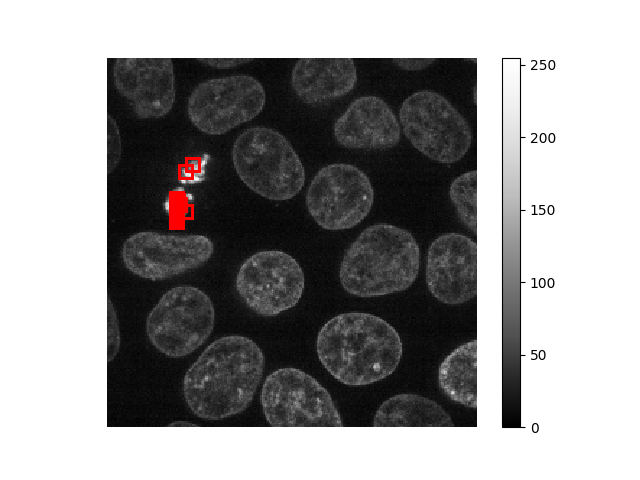
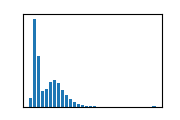

In [52]:
stackview.add_bounding_boxes(image, bb)

Uneven illumination or intensity bias can lead spot detectors (especially prompt-based or ML-based ones like Moondream) to focus only on the brightest region, ignoring fainter but still valid spots.